In [ ]:
#PARTE RESPONSAVEL PELA ANALISE DOS DADOS DE CLASSIFICAÇÃO

Porque é que as pessoas abandonam a empresa?

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [29]:
df = pd.read_csv("../data/raw/employee_data.csv")

In [30]:
df.head()
#mostra que o ficheiro csv foi lido corretamente

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,34,No,Travel_Frequently,702,Research & Development,16,4,Life Sciences,1,838,...,3,80,0,6,3,3,5,2,1,3
1,38,No,Travel_Rarely,833,Research & Development,18,3,Medical,1,1766,...,3,80,1,15,2,3,1,0,1,0
2,51,No,Travel_Rarely,833,Research & Development,1,3,Life Sciences,1,353,...,2,80,0,1,0,2,1,0,0,0
3,60,No,Travel_Rarely,1179,Sales,16,4,Marketing,1,732,...,4,80,0,10,1,3,2,2,2,2
4,23,No,Travel_Rarely,571,Research & Development,12,2,Other,1,1982,...,3,80,0,5,6,4,5,2,1,4


In [31]:
print("Dimensões:", df.shape)
#mostra o numero de linhas e colunas há

Dimensões: (1249, 35)


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1249 entries, 0 to 1248
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1249 non-null   int64 
 1   Attrition                 1249 non-null   object
 2   BusinessTravel            1249 non-null   object
 3   DailyRate                 1249 non-null   int64 
 4   Department                1249 non-null   object
 5   DistanceFromHome          1249 non-null   int64 
 6   Education                 1249 non-null   int64 
 7   EducationField            1249 non-null   object
 8   EmployeeCount             1249 non-null   int64 
 9   EmployeeNumber            1249 non-null   int64 
 10  EnvironmentSatisfaction   1249 non-null   int64 
 11  Gender                    1249 non-null   object
 12  HourlyRate                1249 non-null   int64 
 13  JobInvolvement            1249 non-null   int64 
 14  JobLevel                

In [33]:
# indentificar quantas pessoas abandonaram a empresa e quantas ficaram?
df["Attrition"].value_counts()

Attrition
No     1048
Yes     201
Name: count, dtype: int64

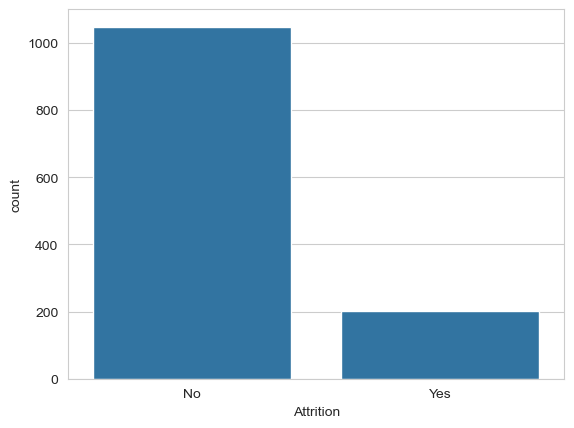

In [34]:
sns.countplot(data=df, x="Attrition")
plt.show()

#aqui mostra os valores da dataframe em modo grafico por conta do import seaborn

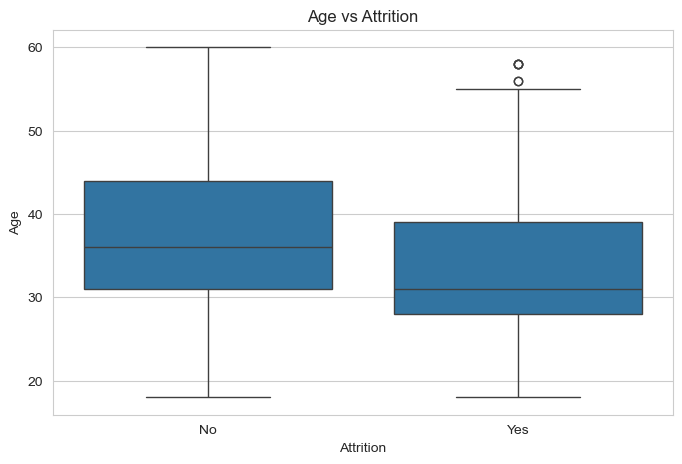

In [35]:
# ver se a idade influencia o abandono?
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="Age")

plt.title("Age vs Attrition")
plt.show()

In [36]:
# Comparação da idade entre colaboradores que permaneceram e colaboradores que abandonaram a empresa.
# Observa-se que a mediana da idade é inferior no grupo que abandonou,
# sugerindo que colaboradores mais jovens apresentam maior tendência para sair da organização.

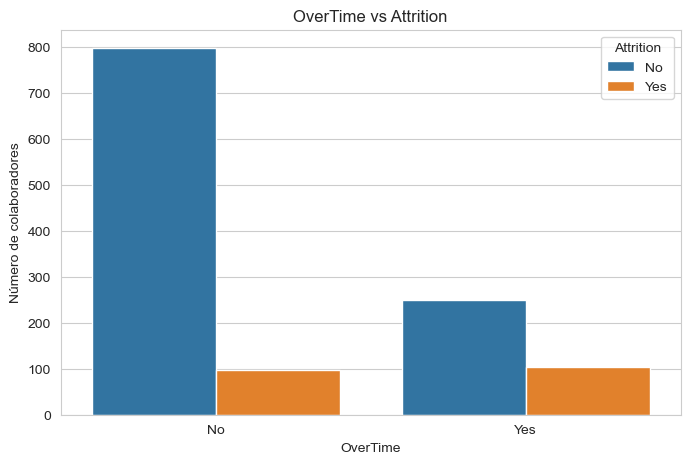

In [37]:
#Quem faz horas extra abandona mais a empresa?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="OverTime", hue="Attrition")

plt.title("OverTime vs Attrition")
plt.xlabel("OverTime")
plt.ylabel("Número de colaboradores")

plt.show()

In [38]:
# Comparação entre OverTime e Attrition.
# Observa-se que colaboradores que realizam horas extra apresentam uma
# proporção de abandono significativamente superior à dos colaboradores
# que não realizam horas extra.
#
# Este resultado sugere que o excesso de carga de trabalho pode estar
# associado a uma maior probabilidade de abandono da empresa.

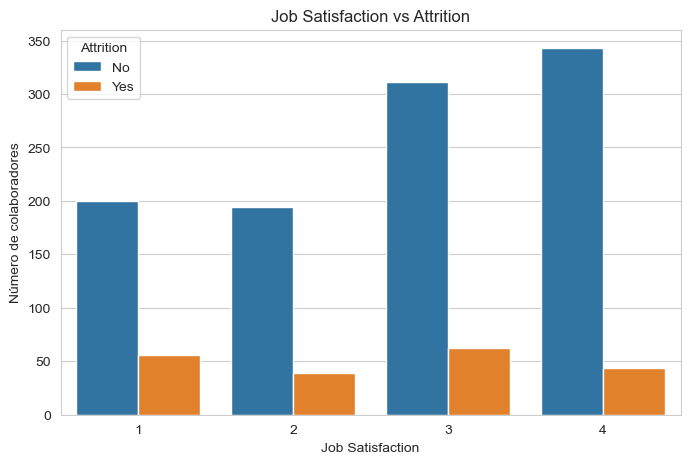

In [39]:
#responder a pergunta sera que os colaboradores menos satisfeitos abandonam mais a empresa?

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="JobSatisfaction", hue="Attrition")

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction")
plt.ylabel("Número de colaboradores")

plt.show()

In [40]:
# Análise da relação entre Job Satisfaction e Attrition.
#
# Observa-se uma tendência para maiores níveis de abandono entre
# colaboradores com níveis mais baixos de satisfação profissional.
#
# Os colaboradores com satisfação elevada (nível 4) apresentam uma
# proporção inferior de abandono quando comparados com colaboradores
# menos satisfeitos.
#
# Apesar desta tendência, a diferença não é tão acentuada quanto a
# observada na variável OverTime.

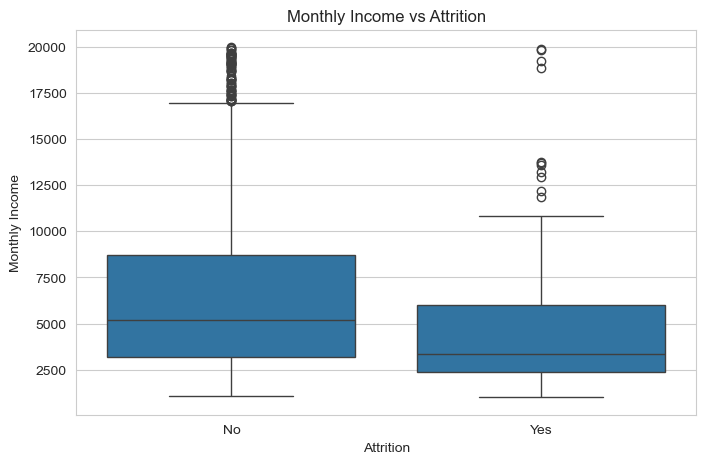

In [41]:
#Pessoas com salários mais baixos abandonam mais a empresa?
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

In [42]:
# Análise da relação entre MonthlyIncome e Attrition.
#
# Observa-se que os colaboradores que abandonaram a empresa apresentam,
# em média, salários inferiores aos colaboradores que permaneceram.
#
# Este resultado sugere que níveis salariais mais baixos podem estar
# associados a uma maior probabilidade de abandono.
#
# O gráfico apresenta ainda alguns outliers, correspondentes a colaboradores
# com salários significativamente superiores à maioria dos restantes.

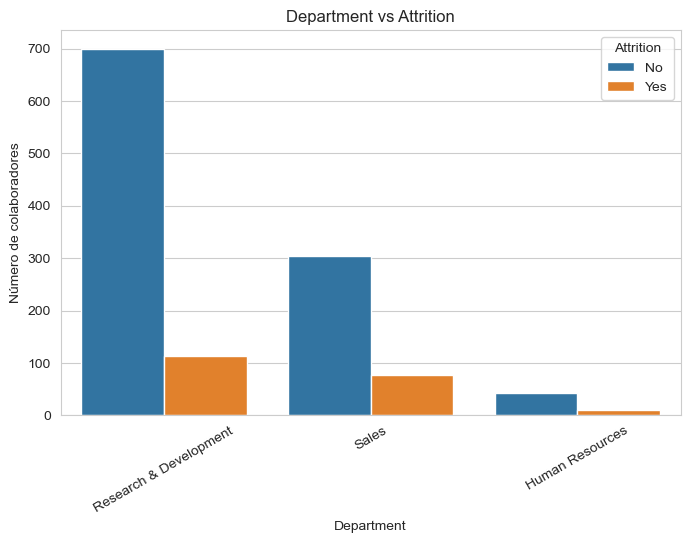

In [43]:
#Há algum departamento onde os colaboradores abandonam mais a empresa?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Department", hue="Attrition")

plt.title("Department vs Attrition")
plt.xlabel("Department")
plt.ylabel("Número de colaboradores")
plt.xticks(rotation=30)

plt.show()

In [44]:
# Análise da relação entre Department e Attrition.
#
# Embora o departamento de Research & Development apresente o maior número
# absoluto de abandonos, este também possui o maior número de colaboradores.
#
# Observa-se que o departamento de Sales apresenta uma proporção de abandono
# relativamente superior, sugerindo que os colaboradores desta área podem
# estar mais propensos a deixar a empresa.

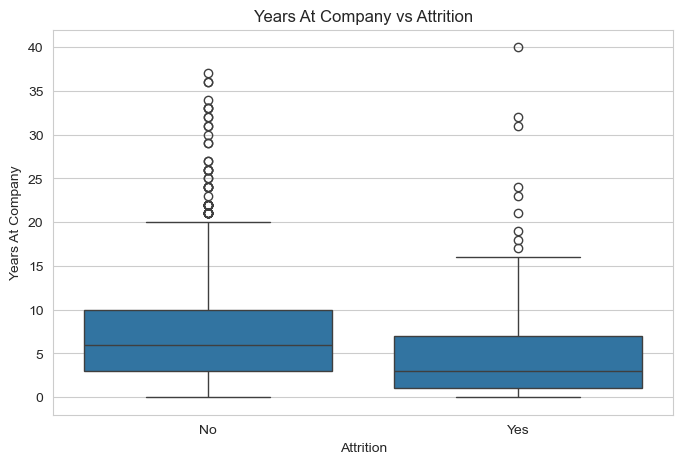

In [45]:
# Os colaboradores que estão há menos tempo na empresa abandonam mais?
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Attrition", y="YearsAtCompany")

plt.title("Years At Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years At Company")

plt.show()

In [46]:
# Análise da relação entre YearsAtCompany e Attrition.
#
# Observa-se que os colaboradores que abandonaram a empresa apresentam,
# em média, menos anos de permanência quando comparados com os que permaneceram.
#
# A mediana dos anos de permanência é inferior no grupo que abandonou,
# sugerindo que o abandono tende a ocorrer com maior frequência nos
# primeiros anos de carreira dentro da organização.
#
# Foram ainda identificados alguns outliers, correspondentes a colaboradores
# que permaneceram muitos anos na empresa antes de abandonarem a organização.

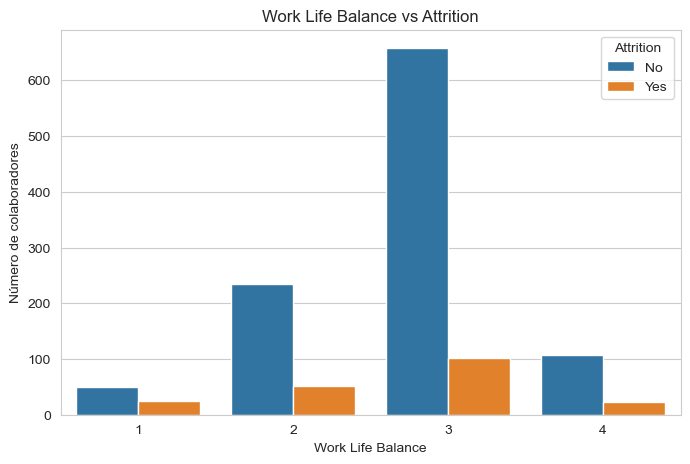

In [47]:
# O equilíbrio entre vida pessoal e trabalho influencia o abandono?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="WorkLifeBalance", hue="Attrition")

plt.title("Work Life Balance vs Attrition")
plt.xlabel("Work Life Balance")
plt.ylabel("Número de colaboradores")

plt.show()

In [48]:
# Análise da relação entre WorkLifeBalance e Attrition.
#
# Observa-se que colaboradores com níveis mais elevados de equilíbrio
# entre vida pessoal e profissional apresentam menores taxas de abandono.
#
# Por outro lado, níveis mais baixos de WorkLifeBalance parecem estar
# associados a uma maior tendência de saída da empresa.
#
# Este resultado sugere que o equilíbrio entre trabalho e vida pessoal
# pode influenciar a retenção dos colaboradores.


# 1 representa muito mau
# 2 representa mau
# 3 representa bom
# 4 representa excelente

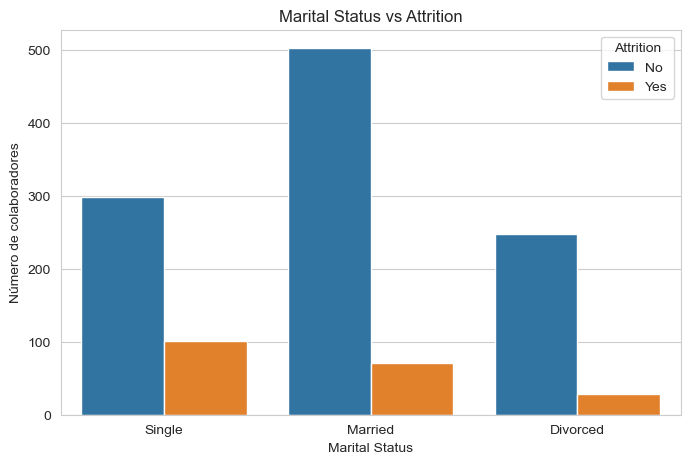

In [49]:
# O estado civil influencia o abandono?
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="MaritalStatus", hue="Attrition")

plt.title("Marital Status vs Attrition")
plt.xlabel("Marital Status")
plt.ylabel("Número de colaboradores")

plt.show()

In [50]:
# Análise da relação entre MaritalStatus e Attrition.
#
# Observa-se que colaboradores solteiros apresentam uma proporção
# superior de abandono quando comparados com colaboradores casados
# ou divorciados.
#
# Os colaboradores casados parecem apresentar maior estabilidade,
# registando uma menor taxa de abandono.
#
# Estes resultados sugerem que fatores pessoais e familiares podem
# estar relacionados com a permanência dos colaboradores na organização.

# Conclusões da EDA Attrition

Após a análise exploratória dos dados, foram identificados vários fatores associados ao abandono de colaboradores.

## Principais conclusões

### Idade
Colaboradores mais jovens apresentam maior tendência para abandonar a empresa.

### OverTime
A realização de horas extra está associada a taxas superiores de abandono.

### Job Satisfaction
Níveis mais baixos de satisfação profissional parecem estar relacionados com maior probabilidade de saída.

### Monthly Income
Colaboradores com salários mais baixos apresentam maior tendência de abandono.

### Department
O departamento de Sales apresenta uma taxa de abandono relativamente superior aos restantes departamentos.

### Years At Company
O abandono ocorre com maior frequência nos primeiros anos de permanência na empresa.

### Work Life Balance
Um melhor equilíbrio entre vida pessoal e profissional parece contribuir para a retenção dos colaboradores.

### Marital Status
Colaboradores solteiros apresentam uma maior taxa de abandono quando comparados com colaboradores casados ou divorciados.

## Conclusão Geral

Os resultados sugerem que fatores relacionados com idade, remuneração, satisfação profissional, horas extra, equilíbrio vida-trabalho e estabilidade pessoal podem influenciar a decisão de um colaborador abandonar a empresa.

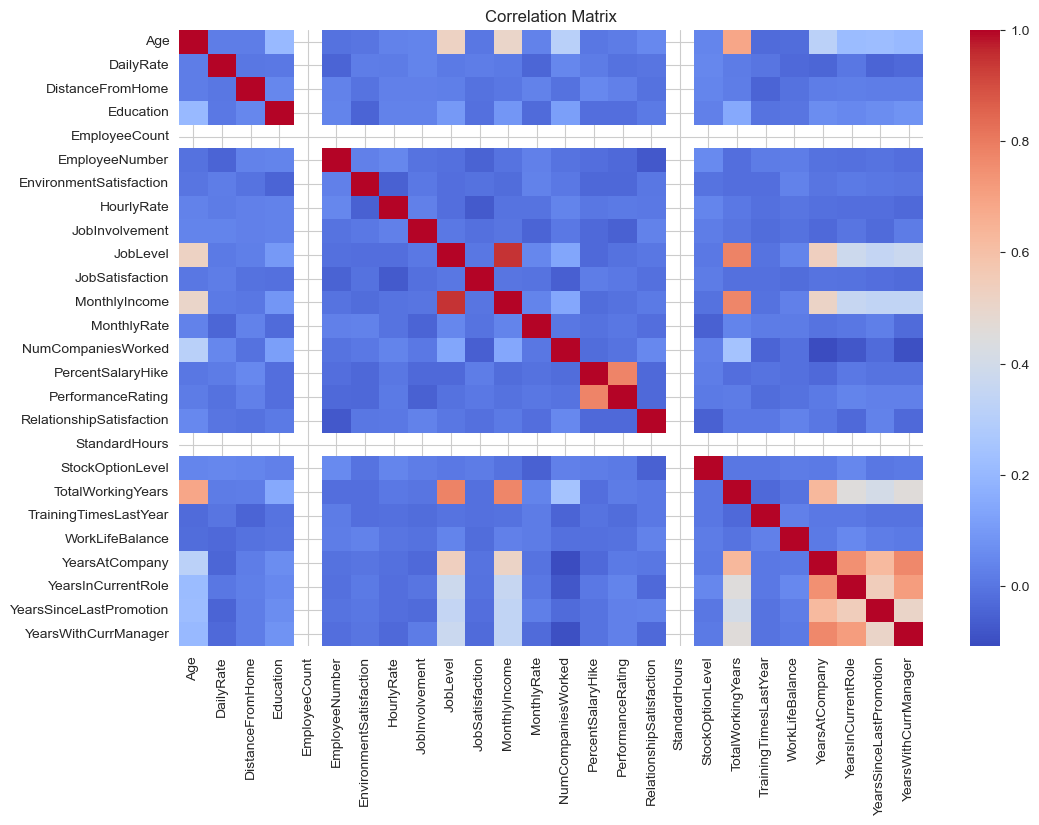

In [51]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()